<a href="https://colab.research.google.com/github/Victor-Tung/CS123a_AM1_term_project/blob/main/CS123a_project_GANTC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Initial setup


In [ ]:
# mounting drive
from google.colab import drive
drive.mount('/content/drive')
# setting up paths to files in drive
folder = '/content/drive/MyDrive/123a_term_project'
ref = f'{folder}/GCF_000022685.1_ASM2268v1_genomic.fna'
evohln_r1 = f'{folder}/SRR17468317_1.fastq'
evohln_r2 = f'{folder}/SRR17468317_2.fastq'
bam_5642 = f'{folder}/5642_1.bam'
evohln_bam_path = f'{folder}/evoHLn.bam'
gff = f'{folder}/genomic.gff'


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#initializing and setting up tools
!apt-get install -y hisat2 samtools
!pip install pysam

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
hisat2 is already the newest version (2.2.1-3).
samtools is already the newest version (1.13-4).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


In [ ]:
# building index from AM1 genome, converting fasta into a easy hisat2 search format
!hisat2-build {ref} /content/am1_index

Settings:
  Output files: "/content/am1_index.*.ht2"
  Line rate: 6 (line is 64 bytes)
  Lines per side: 1 (side is 64 bytes)
  Offset rate: 4 (one in 16)
  FTable chars: 10
  Strings: unpacked
  Local offset rate: 3 (one in 8)
  Local fTable chars: 6
  Local sequence length: 57344
  Local sequence overlap between two consecutive indexes: 1024
  Endianness: little
  Actual local endianness: little
  Sanity checking: disabled
  Assertions: disabled
  Random seed: 0
  Sizeofs: void*:8, int:4, long:8, size_t:8
Input files DNA, FASTA:
  /content/drive/MyDrive/123a_term_project/GCF_000022685.1_ASM2268v1_genomic.fna
Reading reference sizes
  Time reading reference sizes: 00:00:01
Calculating joined length
Writing header
Reserving space for joined string
Joining reference sequences
  Time to join reference sequences: 00:00:00
  Time to read SNPs and splice sites: 00:00:00
Using parameters --bmax 1289958 --dcv 1024
  Doing ahead-of-time memory usage test
  Passed!  Constructing with these para

Bam file for evoHLn

In [ ]:
# Alignment of both fastq files to am1 reference to create evohln bam fil
# current error message is because I already have the bam file in my drive
!hisat2 -p 5 --rna-strandness RF --sensitive \
    -x /content/am1_index \
    -1 {evohln_r1}\
    -2 {evohln_r2}\
    | samtools sort -O BAM -o /content/evoHLn.bam

[E::hts_open_format] Failed to open file "/content/evoHLn.bam.tmp.0000.bam" : File exists
samtools sort: failed to create temporary file "/content/evoHLn.bam.tmp.0000.bam": File exists
(ERR): hisat2-align exited with value 141


In [ ]:
#indexing both the evoHLn and 5642 bam files so that pysam can jump to specific positions
!samtools index /content/evoHLn.bam
!samtools index {bam_5642}

In [ ]:
# copy of bam files in drive to make it so that we do not have to rerun this cell for 30 minutes if collab resets
!cp /content/evoHLn.bam /content/drive/MyDrive/123a_term_project/evoHLn.bam
!cp /content/evoHLn.bam.bai /content/drive/MyDrive/123a_term_project/evoHLn.bam.bai

GANTC Site

In [ ]:
import re

# read the AM1 reference genome FASTA file line by line
with open(ref, 'r') as f:
    lines = f.readlines()

# parsing the FASTA file into a dictionary where keys are chromosome namesand the values are the nt seq
chromosomes ={}
current_chrom =None
current_seq =[]
# each chromosome start with header line with > followed by lines of nt seq, when we hit a new header we will save the prev chromosome seq
# after saving prev chrom seq we will collect the seq for the new chrom and the result is a dic where the key is the chrom name
# note each value is the full nt seq and the key is the chrom name
for line in lines:
    if line.startswith('>'):
        if current_chrom:
            chromosomes[current_chrom] = ''.join(current_seq)
        current_chrom = line.strip().split()[0][1:]
        current_seq = []
    else:
        current_seq.append(line.strip())
# saving last chromosome
chromosomes[current_chrom] = ''.join(current_seq)
# scanning each chrom for GANTC motifs using regex
pattern = re.compile(r'GA[ATGC]TC')
gantc_sites = {}
# essentially finding all positions where GANTC occurs
#will be used in next step to extract read counts from BAM files
for chrom, seq in chromosomes.items():
    positions = [m.start() for m in pattern.finditer(seq)]
    gantc_sites[chrom] = positions
    print(f"{chrom}: {len(positions)} GANTC sites found")

NC_012808.1: 8343 GANTC sites found
NC_012811.1: 1805 GANTC sites found
NC_012807.1: 40 GANTC sites found
NC_012809.1: 37 GANTC sites found
NC_012810.1: 25 GANTC sites found


In [ ]:
import pysam
# evohln BAM uses refseq naming and 5642 uses genbank naming
chrom = 'NC_012808.1'
cp_chrom = 'CP001510.1'
# using a set for fast position lookup during pileup
gantc_set = set(gantc_sites[chrom])
#open bam files
evohln_bam = pysam.AlignmentFile(evohln_bam_path, 'rb')
dsr_bam = pysam.AlignmentFile(bam_5642, 'rb')

evohln_counts ={}
dsr_counts = {}
# count reads overlapping each GANTC position in evoHLn
for col in evohln_bam.pileup(chrom, stepper='nofilter'):
    if col.reference_pos in gantc_set:
        evohln_counts[col.reference_pos] = col.nsegments
# same pileup for 5642 using GenBank chromosome name
for col in dsr_bam.pileup(cp_chrom, stepper='nofilter'):
    if col.reference_pos in gantc_set:
        dsr_counts[col.reference_pos] = col.nsegments
# record positions where read counts differ between the two strains, if 0 then no read
differences =[]
for pos in gantc_set:
    e =evohln_counts.get(pos, 0)
    d = dsr_counts.get(pos, 0)
    if e !=d:
        differences.append({'position': pos, 'evoHLn': e, '5642': d})

print(f"Total differences found: {len(differences)}")
for diff in sorted(differences, key=lambda x: x['position'])[:10]:
    print(f"Position {diff['position']}: evoHLn={diff['evoHLn']} 5642={diff['5642']}")

Total differences found: 8341
Position 17: evoHLn=11 5642=12
Position 217: evoHLn=8 5642=34
Position 283: evoHLn=8 5642=34
Position 436: evoHLn=185 5642=309
Position 466: evoHLn=95 5642=369
Position 488: evoHLn=75 5642=370
Position 924: evoHLn=559 5642=842
Position 1158: evoHLn=12 5642=642
Position 1264: evoHLn=83 5642=1135
Position 1569: evoHLn=121 5642=292


In [ ]:
import pandas as pd
import numpy as np

# build dataframe from results
df = pd.DataFrame(differences)
df = df.sort_values('position').reset_index(drop=True)
print(df.head(10))

   position  evoHLn  5642
0        17      11    12
1       217       8    34
2       283       8    34
3       436     185   309
4       466      95   369
5       488      75   370
6       924     559   842
7      1158      12   642
8      1264      83  1135
9      1569     121   292


In [ ]:
# add pseudocount of 1 to avoid log2(0)
# calculating log2 fold change
# note that neg val means 5642 has more reads and positive means evo has more
df['log2_fold_change'] = np.log2((df['evoHLn']+1) / (df['5642']+1))

print(df[['position', 'evoHLn', '5642', 'log2_fold_change']].head(10))
print(f"\nMean log2 fold change: {df['log2_fold_change'].mean():.3f}")
print(f"Upregulated in evoHLn: {(df['log2_fold_change'] > 0).sum()}")
print(f"Downregulated in evoHLn: {(df['log2_fold_change'] < 0).sum()}")

   position  evoHLn  5642  log2_fold_change
0        17      11    12         -0.115477
1       217       8    34         -1.959358
2       283       8    34         -1.959358
3       436     185   309         -0.736966
4       466      95   369         -1.946419
5       488      75   370         -2.287348
6       924     559   842         -0.590106
7      1158      12   642         -5.628235
8      1264      83  1135         -3.757430
9      1569     121   292         -1.264020

Mean log2 fold change: -4.925
Upregulated in evoHLn: 20
Downregulated in evoHLn: 8321


In [ ]:
# check total read counts for each BAM
# used for checking total mapped reads of each
evohln_bam = pysam.AlignmentFile(evohln_bam_path, 'rb')
dsr_bam = pysam.AlignmentFile(bam_5642, 'rb')

evohln_total = evohln_bam.mapped
dsr_total = dsr_bam.mapped

print(f"evoHLn total mapped reads: {evohln_total:,}")
print(f"5642 total mapped reads: {dsr_total:,}")
print(f"Ratio (5642/evoHLn): {dsr_total/evohln_total:.2f}x")

evoHLn total mapped reads: 99,958,736
5642 total mapped reads: 40,748,416
Ratio (5642/evoHLn): 0.41x


In [ ]:
# normalizing counts by total mapped reads (reads per million)
# trying to make the 2 samples more comparable
evohln_total = 99958736
dsr_total = 40748416

df['evoHLn_norm'] = (df['evoHLn'] / evohln_total) * 1e6
df['5642_norm'] = (df['5642'] / dsr_total) * 1e6

# recalculate fold change with normalized counts
df['log2_fold_change_norm'] = np.log2((df['evoHLn_norm'] + 1) / (df['5642_norm'] + 1))

print(df[['position', 'evoHLn_norm', '5642_norm', 'log2_fold_change_norm']].head(10))
print(f"\nMean log2 fold change: {df['log2_fold_change_norm'].mean():.3f}")
print(f"Upregulated in evoHLn: {(df['log2_fold_change_norm'] > 0).sum()}")
print(f"Downregulated in evoHLn: {(df['log2_fold_change_norm'] < 0).sum()}")

   position  evoHLn_norm  5642_norm  log2_fold_change_norm
0        17     0.110045   0.294490              -0.221765
1       217     0.080033   0.834388              -0.764224
2       283     0.080033   0.834388              -0.764224
3       436     1.850764   7.583117              -1.590153
4       466     0.950392   9.055567              -2.366158
5       488     0.750310   9.080108              -2.525829
6       924     5.592308  20.663380              -1.716403
7      1158     0.120050  15.755214              -3.902976
8      1264     0.830343  27.853843              -3.978578
9      1569     1.210500   7.165923              -1.885244

Mean log2 fold change: -4.564
Upregulated in evoHLn: 0
Downregulated in evoHLn: 8341


Heat Maps

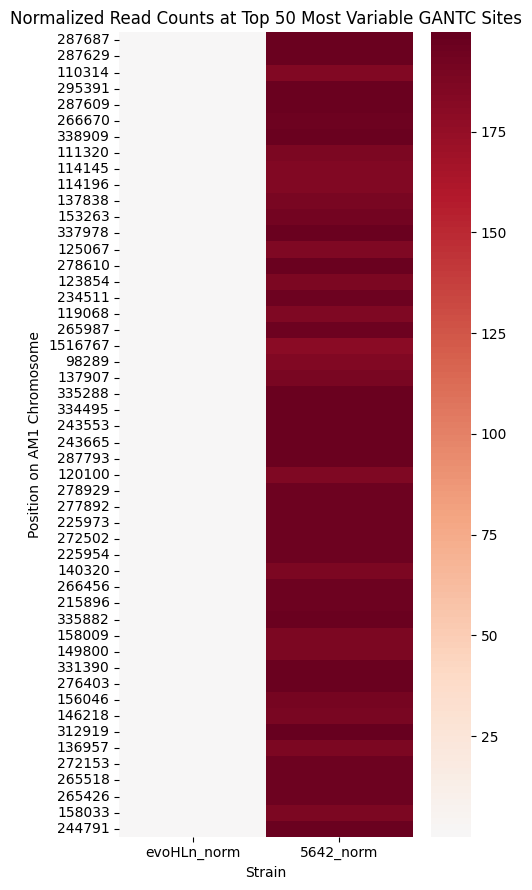

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# select top 50 sites with largest absolute fold change
df['abs_fc_norm'] = df['log2_fold_change_norm'].abs()
top50 = df.nlargest(50, 'abs_fc_norm')
# reason for using normalized values was because of the drastic differences in reads between the 2 strains
# attempt to see any darker shade pop up with evohln
# use normalized counts for heatmap so colors reflect true expression differences
heatmap_data = top50[['evoHLn_norm', '5642_norm']].set_index(top50['position'].astype(str))

plt.figure(figsize=(5, 9))
sns.heatmap(heatmap_data,
            cmap='RdBu_r',
            center=0,
            annot=False,
            yticklabels=True)

plt.title('Normalized Read Counts at Top 50 Most Variable GANTC Sites')
plt.xlabel('Strain')
plt.ylabel('Position on AM1 Chromosome')
plt.tight_layout()

# save to Drive so it is not lost when Colab resets
plt.savefig('/content/drive/MyDrive/123a_term_project/gantc_heatmap_normalized.png', dpi=300)
plt.show()

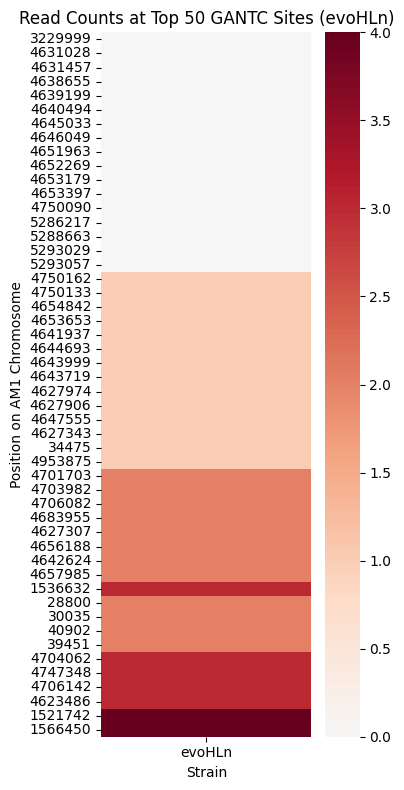

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# take top 50 most variable sites for evoHLn only
top50_evohln = df.nlargest(50, 'abs_fc')
# making heatmap for evohln to doublecheck my sanity after seeing prev heatmap
heatmap_data_evohln = top50_evohln[['evoHLn']].set_index(top50_evohln['position'].astype(str))

plt.figure(figsize=(4, 8))
sns.heatmap(heatmap_data_evohln,
            cmap='RdBu_r',
            center=0,
            annot=False,
            yticklabels=True)

plt.title('Read Counts at Top 50 GANTC Sites (evoHLn)')
plt.xlabel('Strain')
plt.ylabel('Position on AM1 Chromosome')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/123a_term_project/gantc_heatmap_evohln.png', dpi=300)
plt.show()

Significant positions

In [ ]:
# finding positions that appear in both top 50 lists to see any significant positions.
evohln_top = set(df.nlargest(50, 'evoHLn_norm')['position'])
dsr_top = set(df.nlargest(50, '5642_norm')['position'])

overlap = evohln_top.intersection(dsr_top)
print(f"Positions appearing in both top 50 lists: {len(overlap)}")
for pos in sorted(overlap):
    print(f"Position {pos}: evoHLn={df[df['position']==pos]['evoHLn_norm'].values[0]:.2f} 5642={df[df['position']==pos]['5642_norm'].values[0]:.2f}")

Positions appearing in both top 50 lists: 2
Position 428693: evoHLn=79.10 5642=208.03
Position 430538: evoHLn=79.58 5642=207.59
